In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Configuration affichage
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
products = pd.read_csv("products.csv")

print(f"Orders : {orders.shape}")
print(f"Products : {products.shape}")
orders.head()

Orders : (30000, 13)
Products : (49, 4)


,order_id,customer_id,order_date,customer_state,customer_city,product_id,product_category,price,freight_value,payment_type,n_installments,delivery_days,review_score
0,O029800,C11951,2023-01-01,RJ,Petropolis,P0004,electronique,427.77,28.34,credit_card,2,5,5
1,O021225,C11798,2023-01-01,SP,Guarulhos,P0016,maison,169.26,17.84,credit_card,6,4,4
2,O016127,C05355,2023-01-01,RJ,Rio de Janeiro,P0041,jouets,47.17,10.69,credit_card,3,5,5
3,O025785,C01929,2023-01-01,SP,Sao Paulo,P0013,maison,17.73,8.51,boleto,1,4,4
4,O017692,C10629,2023-01-01,MG,Juiz de Fora,P0010,mode,14.54,9.33,debit_card,1,8,5


In [6]:
#permet d'afficher les types de chaque colonne 
orders.dtypes


order_id                       str
customer_id                    str
order_date          datetime64[us]
customer_state                 str
customer_city                  str
product_id                     str
product_category               str
price                      float64
freight_value              float64
payment_type                   str
n_installments               int64
delivery_days                int64
review_score                 int64
dtype: object

In [7]:
orders.describe()
#permet d'afficher les values comme min max ecart type et les quartiles


,order_date,price,freight_value,n_installments,delivery_days,review_score
count,30000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000
mean,2023-12-31 02:46:59.520000,129.543473,15.776045,2.34200,5.527833,4.119033
min,2023-01-01 00:00:00,7.240000,7.540000,1.00000,1.000000,1.000000
25%,2023-07-04 00:00:00,33.750000,10.040000,1.00000,3.000000,4.000000
50%,2023-12-30 00:00:00,72.270000,12.810000,1.00000,5.000000,4.000000
75%,2024-06-29 00:00:00,161.302500,17.580000,3.00000,8.000000,5.000000
max,2024-12-30 00:00:00,746.700000,68.170000,10.00000,19.000000,5.000000
std,NaN,150.388019,8.698926,2.18223,3.215479,0.992185


Le prix moyen d'une commande est de 129,54 BRL, avec des valeurs allant de 7,24 BRL a 746,70 BRL, sans valeurs aberrantes evidentes (pas de prix negatif ou nul).

L'ecart-type, qui mesure la dispersion des valeurs autour de la moyenne, est de 150,39 BRL, soit un ecart-type superieur a la moyenne. Cela indique une forte dispersion des prix : le prix des commandes varie enormement d'un extreme a l'autre.

On observe egalement un ecart notable entre la moyenne (129,54 BRL) et la mediane (72,27 BRL, soit Q2) : la moyenne est nettement plus elevee. Cela revele une distribution asymetrique a droite : la moitie inferieure des prix est resserree (de 7 a 72 BRL), tandis que la moitie superieure s'etale beaucoup plus largement (de 72 a 746 BRL). Cette trainee de commandes a prix eleve tire la moyenne vers le haut.

Conclusion : le prix median (72 BRL) reflete mieux la commande typique que la moyenne.

In [8]:
orders["review_score"].value_counts().sort_index()
#permet d'afficher le nombre de personnes ayant mis une note précise. l'affichage se fait de la pire note (1) à la meilleure (5)


review_score
1      554
2     1820
3     4409
4     9935
5    13282
Name: count, dtype: int64

In [9]:
orders["review_score"].value_counts(normalize=True).sort_index() * 100
#permet d'obtenir une distribution des notes en %

review_score
1     1.846667
2     6.066667
3    14.696667
4    33.116667
5    44.273333
Name: proportion, dtype: float64

La distribution des notes est fortement positive avec une moyenne des notes de 4,11 : 77,4% des clients attribuent une note de 4 ou 5 étoiles (dont 44,3% donnent la note maximale). À l'inverse, seuls 7,9% des clients laissent une note de 1 ou 2 étoiles, traduisant une réelle insatisfaction. Les notes neutres (3 étoiles) représentent 14,7% des avis.

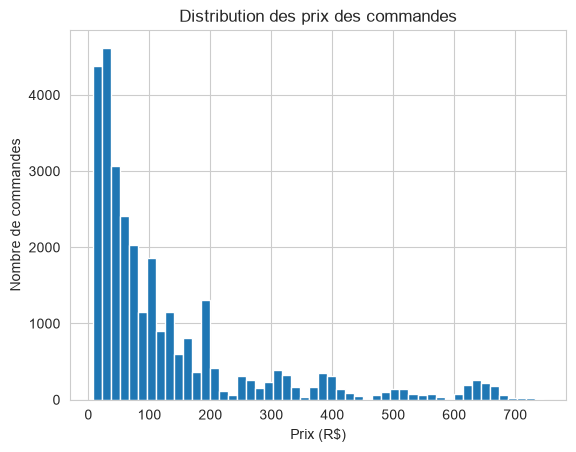

In [10]:
plt.hist(orders["price"], bins=50)
plt.title("Distribution des prix des commandes")
plt.xlabel("Prix (R$)")
plt.ylabel("Nombre de commandes")
plt.show()

L'histogramme confirme l'asymetrie a droite observee dans les statistiques descriptives : la majorite des commandes se situent entre 0 et 200 BRL, avec un pic tres marque autour de 25-50 BRL. Au-dela de 200 BRL, la frequence des commandes diminue fortement mais une trainee s'etend jusqu'a environ 750 BRL, expliquant l'ecart entre la moyenne (129,54 BRL) et la mediane (72,27 BRL).

In [11]:
orders["product_category"].value_counts().head(10)
#permet de selectionner la colonne produt_category de orders et de compter combien y'a de commandes par category pour sortir in fine les 10 categories avec le + de commandes

product_category
beaute          4309
electronique    4256
sport           4188
alimentation    3707
livres          3681
maison          3661
jouets          3138
mode            3060
Name: count, dtype: int64

In [14]:
orders["product_category"].value_counts(normalize=True).head(10)*100
#permet d'afficher la distribution de chaque categorie en %

product_category
beaute          14.363333
electronique    14.186667
sport           13.960000
alimentation    12.356667
livres          12.270000
maison          12.203333
jouets          10.460000
mode            10.200000
Name: proportion, dtype: float64

Le dataset comporte 8 categories de produits, avec une repartition relativement equilibree en volume de commandes : beaute (14,4%), electronique (14,2%) et sport (14,0%) suivies de alimentation, livres et maison (~12% chacune), puis jouets et mode (~10% chacune).

In [16]:
orders["customer_state"].value_counts()
#permet d'afficher le nombre de clients ainsi que de commandes par pays. 

customer_state
SP    10622
RJ     4337
MG     3268
BA     2407
RS     2079
PR     1943
PE     1643
PA     1388
CE     1275
SC     1038
Name: count, dtype: int64

In [18]:
orders["customer_state"].value_counts(normalize=True)*100

customer_state
SP    35.406667
RJ    14.456667
MG    10.893333
BA     8.023333
RS     6.930000
PR     6.476667
PE     5.476667
PA     4.626667
CE     4.250000
SC     3.460000
Name: proportion, dtype: float64

SP concentre a elle seule plus d'un tiers des commandes (35,4%), loin devant Rio (14,5%) et Minas Gerais (10,9%). A eux trois ces etats representent deja plus de 60% du volume total.
Cote business, ca donne une bonne indication sur ou concentrer les efforts logistiques en priorite (entrepots, transporteurs) : SP, RJ et MG en premier.

In [20]:
orders["year"] = orders["order_date"].dt.year
orders["month"] = orders["order_date"].dt.month
orders["year_month"] = orders["order_date"].dt.to_period("M")
orders["weekday"] = orders["order_date"].dt.day_name()
#utile pour la suite afin de faire des groupby()

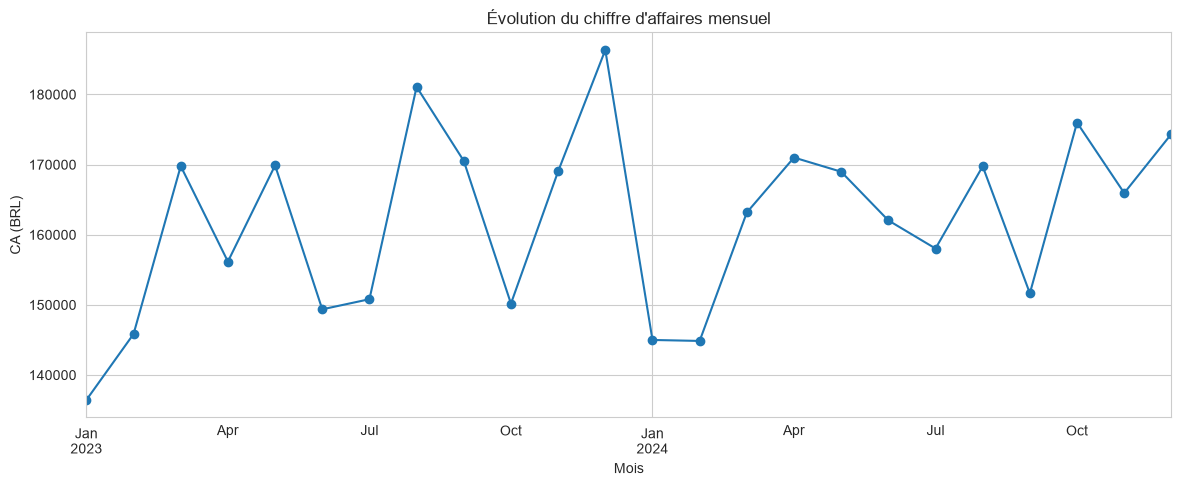

In [23]:
ca_mensuel = orders.groupby("year_month")["price"].sum()

plt.figure(figsize=(14, 5))
ca_mensuel.plot(kind="line", marker="o")
plt.title("Évolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("CA (BRL)")
plt.grid(True)
plt.show()

Le CA mensuel varie fortement d'un mois a l'autre. Le pic le plus marque de toute la periode se situe en novembre 2023 (~186k BRL) lie à la periode Black Friday. On observe une chute nette en decembre 2023 et janvier 2024, avant une reprise progressive au cours de l'annee 2024. Globalement, le CA de 2024 semble legerement superieur a celui de 2023, meme si aucun mois de 2024 n'atteint le pic de novembre 2023.

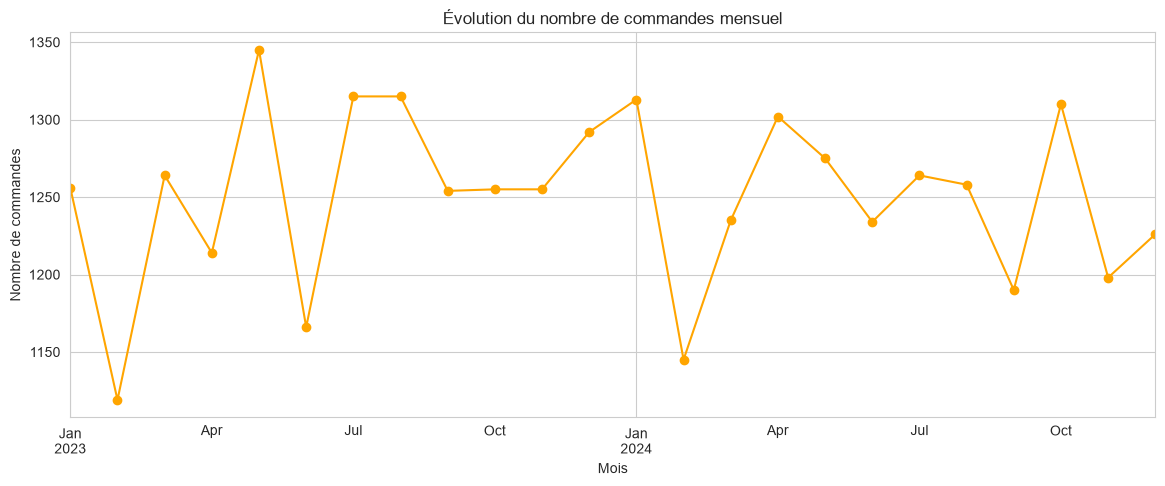

In [25]:
commandes_mensuel = orders.groupby("year_month").size()

plt.figure(figsize=(14, 5))
commandes_mensuel.plot(kind="line", marker="o", color="orange")
plt.title("Évolution du nombre de commandes mensuel")
plt.xlabel("Mois")
plt.ylabel("Nombre de commandes")
plt.grid(True)
plt.show()

Ce qui est interessant ici, c'est que le pic du nombre de commandes n'est pas en novembre 2023 comme pour le CA — il est plutot vers mai 2023 (environ 1345 commandes). En novembre, le volume est eleve aussi (~1310) mais c'est pas le record.

Ca veut dire que le pic de CA de novembre ne vient pas juste du fait qu'il y a eu plus de commandes ce mois-la. Il doit y avoir autre chose : soit les gens ont achete des produits plus chers, soit ils ont achete plus d'articles par commande. A verifier avec le panier moyen mensuel juste apres.

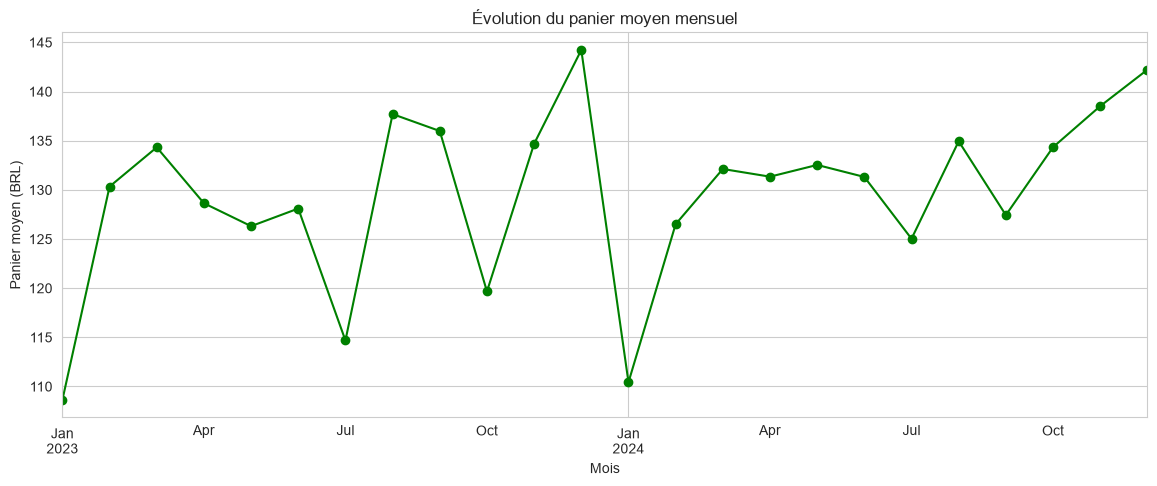

In [26]:
panier_moyen_mensuel = orders.groupby("year_month")["price"].mean()

plt.figure(figsize=(14, 5))
panier_moyen_mensuel.plot(kind="line", marker="o", color="green")
plt.title("Évolution du panier moyen mensuel")
plt.xlabel("Mois")
plt.ylabel("Panier moyen (BRL)")
plt.grid(True)
plt.show()

Ce graphique confirme l'hypothese : le pic de panier moyen se trouve bien en novembre 2023 (~144 BRL). Ca explique le pic de CA de ce mois-la, meme si le volume de commandes n'etait pas record.

Fait interessant : juste apres, en decembre 2023 et janvier 2024, le panier moyen s'effondre au plus bas de toute la periode (~108-110 BRL). Les clients ont donc beaucoup depense en novembre, probablement lie au Black Friday, puis sont revenus a des achats plus modestes juste apres.

In [27]:
# CA de décembre 2023 vs décembre 2024
dec_2023 = orders[(orders["year"] == 2023) & (orders["month"] == 12)]["price"].sum()
dec_2024 = orders[(orders["year"] == 2024) & (orders["month"] == 12)]["price"].sum()

print(f"CA décembre 2023 : {dec_2023:.2f} BRL")
print(f"CA décembre 2024 : {dec_2024:.2f} BRL")
print(f"Évolution : {(dec_2024 - dec_2023) / dec_2023 * 100:.1f}%")

# Pareil pour janvier
jan_2023 = orders[(orders["year"] == 2023) & (orders["month"] == 1)]["price"].sum()
jan_2024 = orders[(orders["year"] == 2024) & (orders["month"] == 1)]["price"].sum()

print(f"\nCA janvier 2023 : {jan_2023:.2f} BRL")
print(f"CA janvier 2024 : {jan_2024:.2f} BRL")
print(f"Évolution : {(jan_2024 - jan_2023) / jan_2023 * 100:.1f}%")

CA décembre 2023 : 186349.22 BRL
CA décembre 2024 : 174368.01 BRL
Évolution : -6.4%

CA janvier 2023 : 136440.82 BRL
CA janvier 2024 : 144996.40 BRL
Évolution : 6.3%


Decembre ne progresse pas d'une annee sur l'autre : le CA baisse de 6,4% entre decembre 2023 (186 349 BRL) et decembre 2024 (174 368 BRL). A l'inverse, janvier progresse de 6,3% entre 2023 et 2024, ce qui va a l'encontre de l'hypothese d'un creux post-fetes.

In [28]:
orders.groupby("weekday").size().sort_values(ascending=False)
#affiche le nombre de commande par jour trier par ordre decroissant

weekday
Sunday       4364
Thursday     4355
Monday       4306
Saturday     4295
Wednesday    4290
Friday       4212
Tuesday      4178
dtype: int64

Le nombre de commande par jour de la semaine est très homogène, le jour de la semaine ne semble pas etre un facteur determinant du comportement d'achat sur ce marketplace. Il n'y a donc pas d'interet particulier a cibler des promotions sur un jour precis de la semaine plutot qu'un autre.

In [29]:
cat_stats = orders.groupby("product_category").agg(
    nb_commandes=("order_id", "count"),
    ca_total=("price", "sum"),
    panier_moyen=("price", "mean"),
    note_moyenne=("review_score", "mean"),
    delai_moyen=("delivery_days", "mean"),
).round(2).sort_values("ca_total", ascending=False)

print(cat_stats)

                  nb_commandes    ca_total  panier_moyen  note_moyenne  \
product_category                                                         
electronique              4256  1728772.61        406.20          4.12   
sport                     4188   737584.57        176.12          4.12   
maison                    3661   451113.64        123.22          4.11   
mode                      3060   301479.62         98.52          4.12   
beaute                    4309   224499.11         52.10          4.11   
jouets                    3138   198919.81         63.39          4.13   
alimentation              3707   148636.44         40.10          4.11   
livres                    3681    95298.39         25.89          4.13   

                  delai_moyen  
product_category               
electronique             5.50  
sport                    5.59  
maison                   5.59  
mode                     5.51  
beaute                   5.58  
jouets                   5.51  
ali

Ce tableau montre un truc important : Le volume de commandes n'est PAS un bon indicateur du CA généré.

"Beaute" est la categorie qui a le plus de commandes (4309), mais elle finit seulement 7eme en CA (224 499 BRL). A l'inverse, "electronique" a un volume proche (4256 commandes) mais genere plus du double du CA de n'importe quelle autre categorie (1 728 772 BRL) grace a son panier moyen bien plus eleve (406 BRL contre 52 BRL pour beaute, soit presque 8 fois plus cher).

La note moyenne (4.11 a 4.13) et le delai de livraison (5.45 a 5.59 jours) sont tres similaires partout, la categorie n'a pas l'air d'influencer la satisfaction client.

In [30]:
state_stats = orders.groupby("customer_state").agg(
    nb_commandes=("order_id", "count"),
    ca_total=("price", "sum"),
    panier_moyen=("price", "mean"),
    note_moyenne=("review_score", "mean"),
    delai_moyen=("delivery_days", "mean"),
).round(2).sort_values("ca_total", ascending=False)

print(state_stats)

                nb_commandes    ca_total  panier_moyen  note_moyenne  \
customer_state                                                         
SP                     10622  1387804.94        130.65          4.26   
RJ                      4337   550314.53        126.89          4.24   
MG                      3268   420011.94        128.52          4.27   
BA                      2407   316937.02        131.67          3.64   
RS                      2079   260517.01        125.31          4.23   
PR                      1943   255451.46        131.47          4.26   
PE                      1643   207987.05        126.59          3.63   
PA                      1388   177535.31        127.91          3.69   
CE                      1275   168394.47        132.07          3.67   
SC                      1038   141350.46        136.18          4.24   

                delai_moyen  
customer_state               
SP                     4.66  
RJ                     4.66  
MG             


D'un cote, SP, RJ, MG, RS, PR et SC : livraison rapide (environ 4.6-4.7 jours) et bonne note moyenne (4.23-4.27). De l'autre, BA, PE, PA et CE : delai quasi deux fois plus long (8.4-8.6 jours) et note nettement plus basse (3.63-3.69).

Ca confirme une intuition logique : plus ca met de temps a arriver, plus les clients sont mecontents. Ces 4 etats sont donc une vraie piste d'amelioration : ameliorer la logistique la-bas (entrepot regional, meilleur transporteur) pourrait vraiment faire remonter la satisfaction.

Sinon, SP reste largement en tete niveau CA (1 387 804 BRL), ce qui suit la logique de son gros volume de commandes deja vu avant.

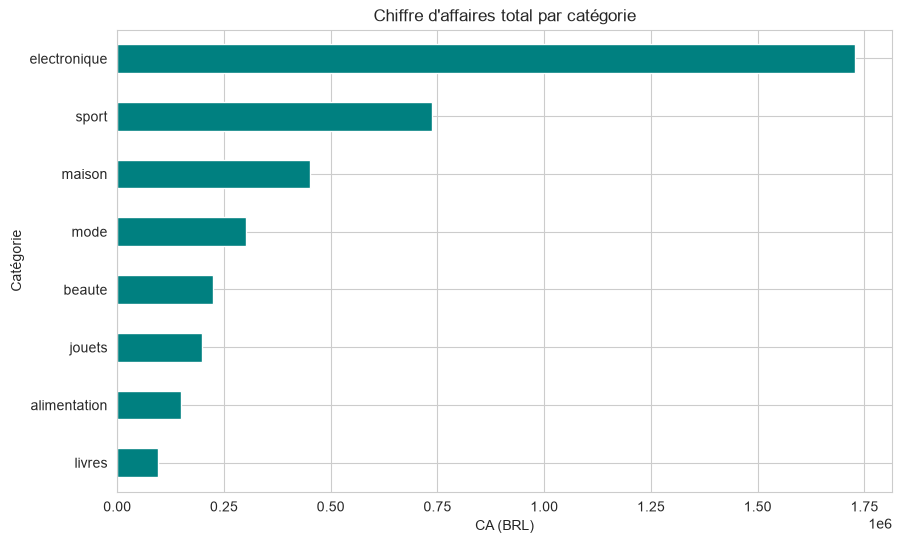

In [31]:
cat_stats["ca_total"].sort_values().plot(kind="barh", figsize=(10, 6), color="teal")
plt.title("Chiffre d'affaires total par catégorie")
plt.xlabel("CA (BRL)")
plt.ylabel("Catégorie")
plt.show()

Ce graphique confirme visuellement la domination ecrasante de la categorie electronique en termes de CA : sa barre est plus de deux fois plus longue que celle de sport (2e position) et depasse largement toutes les autres categories reunies presque. A l'oppose, livres genere le CA le plus faible, loin derriere le reste.

Cet ecart montre qu'une petite poignee de categories a prix eleve (electronique, sport) domine dans la valeur du CA total.

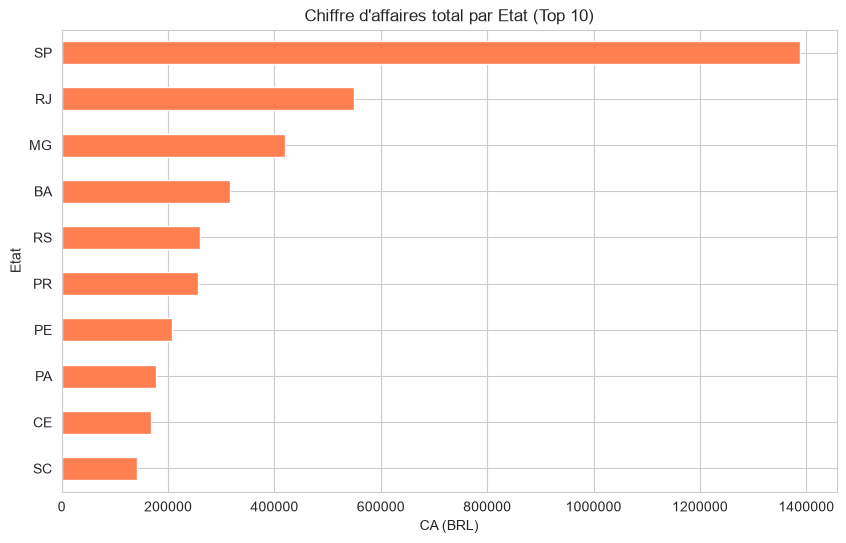

In [33]:
# On trie le CA par etat du plus grand au plus petit, puis on garde le top 10
top10_states = state_stats["ca_total"].sort_values(ascending=False).head(10)

# On re-trie en ordre croissant pour un bel affichage en barres horizontales
top10_states = top10_states.sort_values()

# Creation du graphique en barres horizontales
top10_states.plot(kind="barh", figsize=(10, 6), color="coral")
plt.title("Chiffre d'affaires total par Etat (Top 10)")
plt.xlabel("CA (BRL)")
plt.ylabel("Etat")

# Desactive la notation scientifique (1e6) pour un affichage plus lisible
plt.ticklabel_format(style="plain", axis="x")

plt.show()

Ce graphique confirme le poids ecrasant de SP, avec un CA presque 2,5 fois superieur a celui de RJ, le 2e etat.  SP est donc de loin le marche le plus important pour ce marketplace, coherent avec son poids demographique et economique au Bresil.

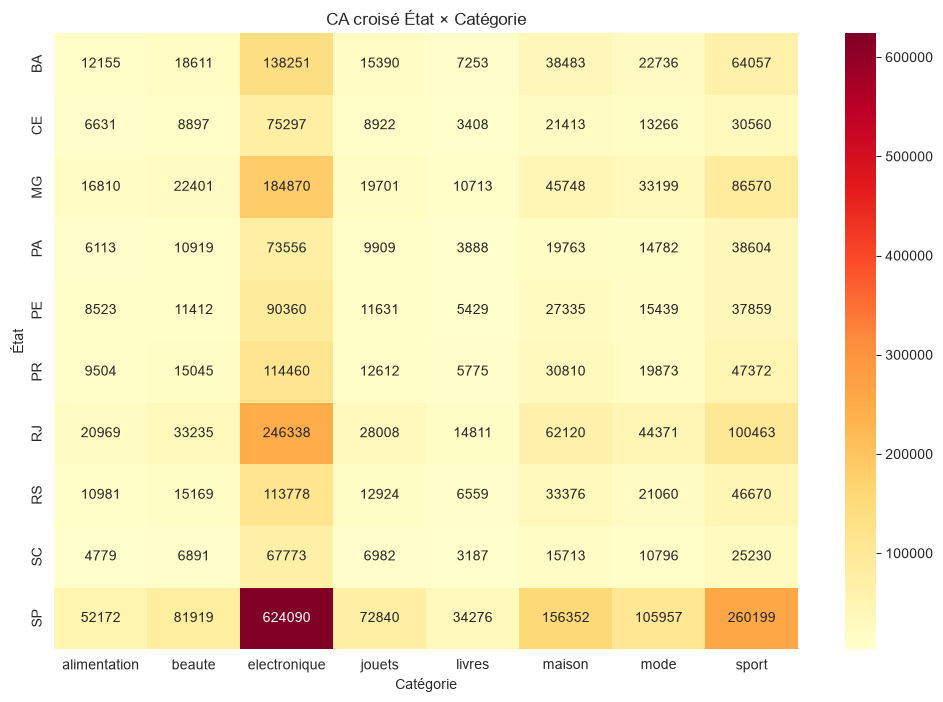

In [34]:
# Creation du tableau croise : etat en lignes, categorie en colonnes, valeur = somme des prix
heatmap_data = pd.crosstab(
    orders["customer_state"],
    orders["product_category"],
    values=orders["price"],
    aggfunc="sum"
)

# Affichage du tableau croise sous forme de heatmap (carte de chaleur)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("CA croisé État × Catégorie")
plt.xlabel("Catégorie")
plt.ylabel("État")
plt.show()

La case la plus intense SP + electronique (624 090 BRL), tres largement devant tout le reste. SP domine sur toutes les categories (chaque colonne a sa valeur la plus haute sur la ligne SP), ce qui colle avec son poids economique deja observe.

En revanche, la colonne electronique se distingue clairement des autres categories, quel que soit l'etat : meme dans les petits etats comme BA ou CE, electronique genere plus de CA que les autres categories. Ca confirme que c'est une categorie a fort panier moyen partout au Bresil, pas juste a SP.

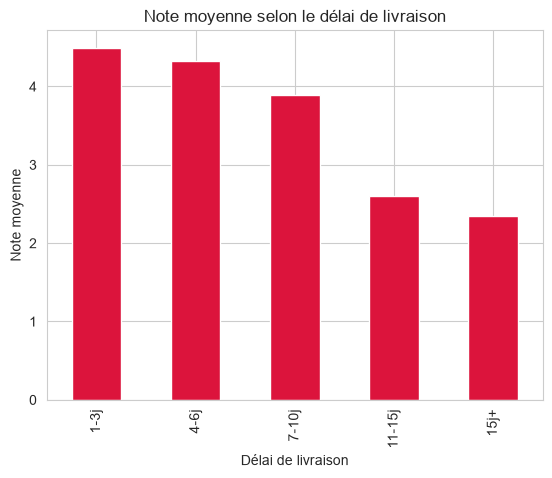

In [35]:
# On regroupe les delais de livraison en tranches (buckets) plutot que des jours precis
orders["delivery_bucket"] = pd.cut(
    orders["delivery_days"],
    bins=[0, 3, 6, 10, 15, 100],
    labels=["1-3j", "4-6j", "7-10j", "11-15j", "15j+"]
)

# On calcule la note moyenne pour chaque tranche de delai, puis on affiche en barres
orders.groupby("delivery_bucket")["review_score"].mean().plot(kind="bar", color="crimson")
plt.title("Note moyenne selon le délai de livraison")
plt.xlabel("Délai de livraison")
plt.ylabel("Note moyenne")
plt.show()

Ce graphique confirme clairement l'hypothese de depart : plus le delai de livraison augmente, plus la note baisse, et de facon quasi lineaire. Mais le vrai point important se situe entre 10 et 15 jours : la note chute brutalement de 3.9 a 2.6, alors que jusqu'a 10 jours la baisse etait plus progressive.

Concretement, ca veut dire qu'il y a un seuil critique autour de 10 jours : en dessous, les clients restent plutot satisfaits (note > 3.8), au-dessus, la satisfaction s'effondre. Il faudrait donc assurer une livraison < 10 jours.

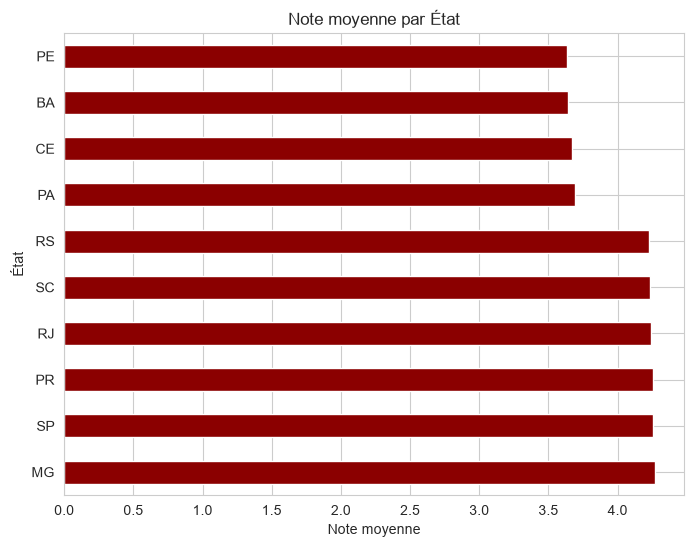

In [41]:
# Note moyenne par etat, triee de la pire a la meilleure
note_par_etat = orders.groupby("customer_state")["review_score"].mean().sort_values(ascending=False)

# Affichage en barres horizontales
note_par_etat.plot(kind="barh", figsize=(8, 6), color="darkred")
plt.title("Note moyenne par État")
plt.xlabel("Note moyenne")
plt.ylabel("État")
plt.show()

4 etats se detachent avec des notes plus basses (PE, BA, CE, PA — entre 3,6 et 3,7), pendant que les 6 autres sont tous regroupes autour de 4,2-4,3.

Ca confirme que ces 4 etats sont un axe d'amelioration prioritaire pour ameliorer la satisfaction client.

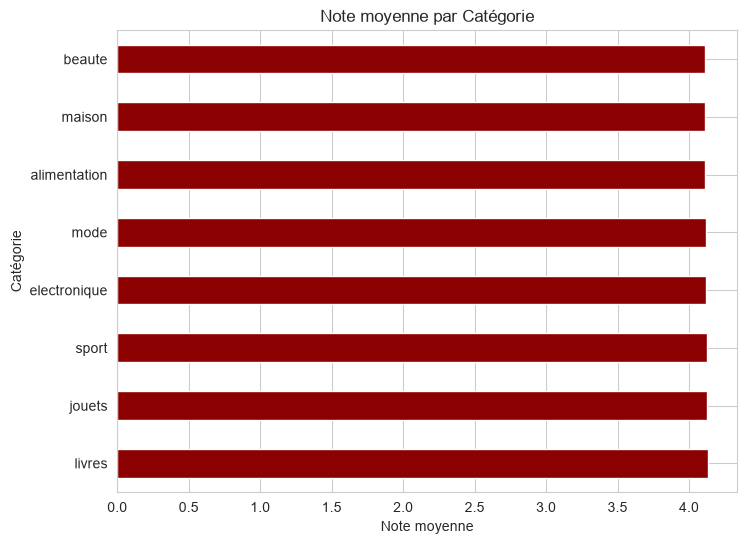

In [42]:
# Note moyenne par categorie, trie de la pire a la meilleure
note_par_categorie = orders.groupby("product_category")["review_score"].mean().sort_values(ascending=False)

# Affichage en barres horizontales
note_par_categorie.plot(kind="barh", figsize=(8, 6), color="darkred")
plt.title("Note moyenne par Catégorie")
plt.xlabel("Note moyenne")
plt.ylabel("Catégorie")
plt.show()

comme deja vu avant, ce graphique confirme que que la satisfaction client ne depend pas du type de produit achete, mais bien d'autres facteurs comme le delai de livraison, qu'on a deja identifie comme le vrai levier.

In [45]:
taux_insatisfaction = (
    orders[orders['review_score'] <= 2]
    .groupby('customer_state')
    .size()
    .div(orders.groupby('customer_state').size())
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(taux_insatisfaction)

customer_state
BA    20.81
PE    20.57
PA    19.88
CE    18.20
RS     4.76
SP     4.54
RJ     4.38
MG     4.25
PR     4.07
SC     3.66
dtype: float64


Les 4 memes etats (BA, PE, PA, CE) ressortent avec un taux d'insatisfaction entre 18% et 21%, soit 4 a 5 fois plus eleve que les autres etats (3.7% a 4.8%). Ca confirme que le probleme de delai de livraison dans ces regions a un impact direct et massif sur la satisfaction client.

In [46]:
orders.groupby("customer_state").agg(
    delai_moyen=("delivery_days", "mean"),
    note_moyenne=("review_score", "mean"),
    pct_mauvaises_notes=("review_score", lambda x: (x <= 2).mean() * 100),
).sort_values("pct_mauvaises_notes", ascending=False)

,delai_moyen,note_moyenne,pct_mauvaises_notes
customer_state,,,
BA,8.552555,3.638970,20.814292
PE,8.571516,3.634206,20.572124
PA,8.561960,3.693084,19.884726
CE,8.390588,3.672941,18.196078
RS,4.733045,4.228475,4.761905
SP,4.661834,4.258708,4.537752
RJ,4.661517,4.240719,4.380908
MG,4.618115,4.268054,4.253366
PR,4.687082,4.255275,4.065878


Une nouvelle fois, ces 4 etats (BA-PE-PA-CE) representent donc un vrai "score de risque" logistique : ce sont les priorites claires pour ameliorer la satisfaction client, probablement via un renforcement logistique local (entrepot regional, meilleur transporteur).

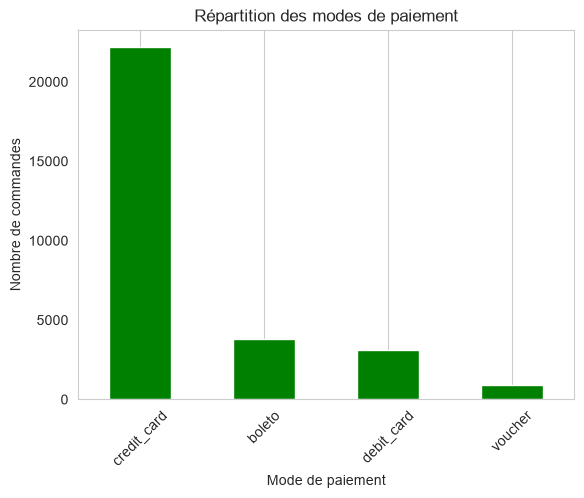

In [51]:
repartition_paiement = orders["payment_type"].value_counts()

repartition_paiement.plot(kind="bar", color="green")
plt.title("Répartition des modes de paiement")
plt.xlabel("Mode de paiement")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

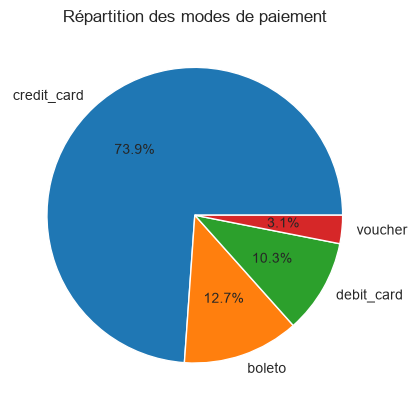

In [53]:
repartition_paiement = orders["payment_type"].value_counts()

repartition_paiement.plot(kind="pie", autopct="%1.1f%%")
plt.title("Répartition des modes de paiement")
plt.show()

On peut observer que 74% des ventes sont payées en Carte de crédit

In [55]:
panierMoyenParPaiement=orders.groupby("payment_type")["price"].mean().sort_values(ascending=False)
print(panierMoyenParPaiement)

payment_type
credit_card    130.424355
debit_card     129.532193
voucher        126.762112
boleto         125.114079
Name: price, dtype: float64


Le panier moyen est quasiment identique selon le mode de paiement utilise (entre 125 et 130 BRL, un ecart de seulement 5 BRL). Le mode de paiement n'influence donc pas le montant depense.

In [57]:
credit_orders = orders[orders["payment_type"] == "credit_card"]

distribution_mensualites = credit_orders["n_installments"].value_counts(normalize=True).sort_index()*100
print(distribution_mensualites)

n_installments
1     39.403510
2     20.502640
3     19.807788
6     15.259667
10     5.026395
Name: proportion, dtype: float64


Parmi les paiements en carte de credit, seuls 39% sont regles en une seule fois (comptant). Plus de 60% des clients choisissent d'etaler leur paiement, avec des paliers marques a 2, 3, 6 et 10 mensualites.

In [58]:
correlation = credit_orders["n_installments"].corr(credit_orders["price"])
print(f"Corrélation : {correlation:.2f}")

Corrélation : 0.01


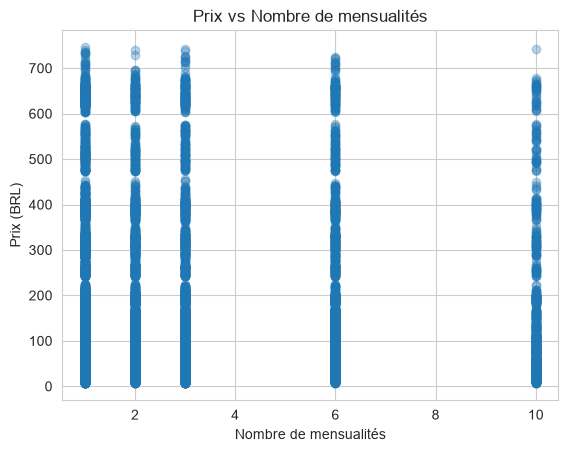

In [59]:
plt.scatter(credit_orders["n_installments"], credit_orders["price"], alpha=0.3)
plt.title("Prix vs Nombre de mensualités")
plt.xlabel("Nombre de mensualités")
plt.ylabel("Prix (BRL)")
plt.show()

contrairement à l'intuition humaine, il y'a aucune corrélation entre le prix d'un article et le nombre de mensualites choisies (coefficient de correlation quasi nul : 0.01).De plus, le nuage de points confirme visuellement ce resultat : pour chaque palier de mensualites (1, 2, 3, 6, 10), les prix sont distribues de facon quasi identique.
Cela signifie que que le choix du nombre de mensualites depend des preferences personnelles que du montant.
